## NLP Mini Project :text Processing and Sentiment Analysis


In [1]:
import pandas as pd
import seaborn as sns
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [2]:
df=pd.read_csv('IMDB Dataset.csv', engine='python', on_bad_lines='skip')
display(df.head())

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
stop_word=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()
def preprocess(text):
  text=text.lower()
  tokens=word_tokenize(text)
  tokens=[token for token in tokens if token.isalpha()]
  tokens=[token for token in tokens if token not in stop_word]
  tokens=[lemmatizer.lemmatize(token) for token in tokens]
  return ' '.join(tokens)

df['clean_review']=df['review'].apply(preprocess)
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


In [4]:
vectorizer =TfidfVectorizer(max_features=5000)
X=vectorizer.fit_transform(df['clean_review'])
y=df['sentiment']

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
model=MultinomialNB()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [7]:
from sklearn.metrics import classification_report
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8582311408398365
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      2719
    positive       0.85      0.87      0.86      2663

    accuracy                           0.86      5382
   macro avg       0.86      0.86      0.86      5382
weighted avg       0.86      0.86      0.86      5382



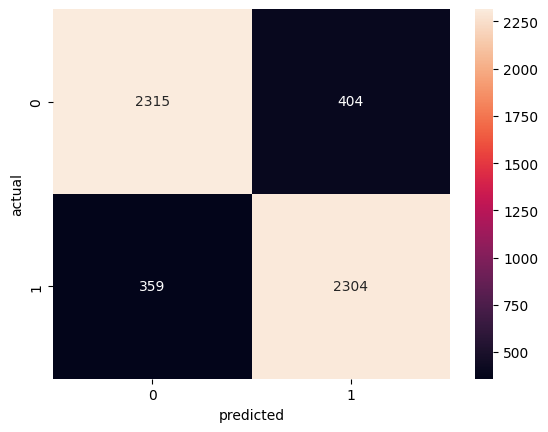

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()

In [9]:
text=['This movie was fantastic and inspiring']
clean=preprocess(text[0])
vector=vectorizer.transform([clean])
prediction =model.predict(vector)
print("preducted sentiment:",prediction[0])

preducted sentiment: positive


In [10]:
text=['This movie was good but the plot was diappointing']
clean=preprocess(text[0])
vector=vectorizer.transform([clean])
prediction =model.predict(vector)
print("preducted sentiment:",prediction[0])

preducted sentiment: negative


In [11]:

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [12]:
models = {
     "Naive bayes": MultinomialNB(),
     "Logistic Regression": LogisticRegression(),
     "Support Vector Machine": SVC(),
     "Random Forest": RandomForestClassifier(),
     "Gradient Boosting": GradientBoostingClassifier()

}

In [13]:
results=[]
for name,model in models.items():
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  f1=f1_score(y_test,y_pred,pos_label='positive')
  results.append([name,accuracy,f1])

In [14]:
results_df =pd.DataFrame(results,columns=['Model','Accuracy','F1 Score'])
results_df

,Model,Accuracy,F1 Score
0,Naive bayes,0.858231,0.857941
1,Logistic Regression,0.883501,0.884467
2,Support Vector Machine,0.888146,0.889257
3,Random Forest,0.847640,0.846442
4,Gradient Boosting,0.805834,0.815599


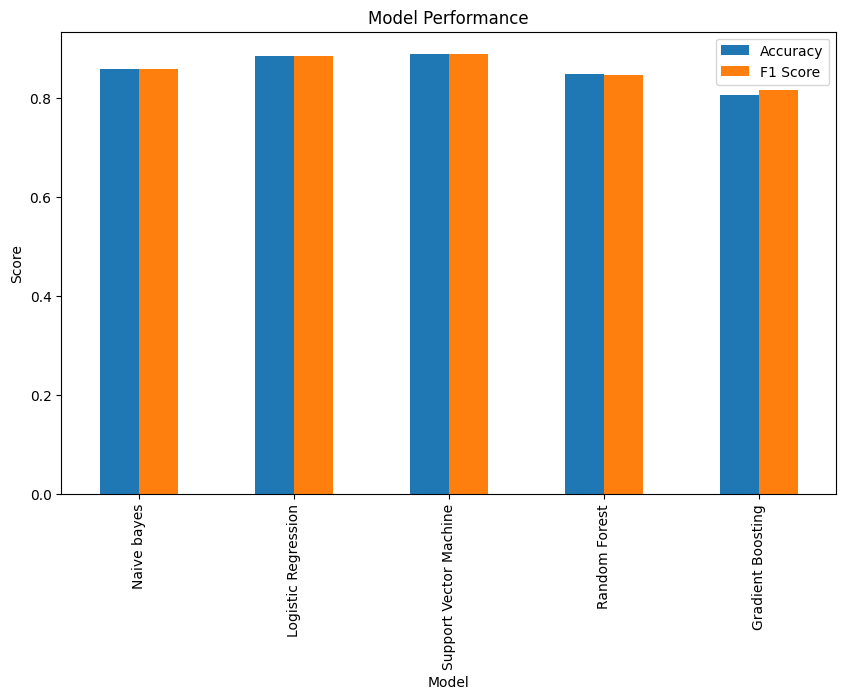

In [15]:
results_df.set_index("Model")[["Accuracy","F1 Score"]].plot(kind="bar",figsize=(10,6))
plt.title("Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.show()

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the Logistic Regression model
log_reg_model = LogisticRegression(solver='liblinear', random_state=42)


# Define the parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Initialize GridSearchCV
# 'accuracy' is a common scoring metric for classification tasks
grid_search = GridSearchCV(log_reg_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)

Best parameters found:  {'C': 1}
Best cross-validation accuracy:  0.878513356562137


In [17]:
# Get the best model from the grid search
best_log_reg_model = grid_search.best_estimator_

# Make predictions with the tuned model
y_pred_tuned = best_log_reg_model.predict(X_test)

# Evaluate the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned, pos_label='positive')

print(f"Tuned Logistic Regression Accuracy: {accuracy_tuned:.4f}")
print(f"Tuned Logistic Regression F1 Score: {f1_tuned:.4f}")
print("\nClassification Report for Tuned Logistic Regression:\n")
print(classification_report(y_test, y_pred_tuned))

Tuned Logistic Regression Accuracy: 0.8839
Tuned Logistic Regression F1 Score: 0.8848

Classification Report for Tuned Logistic Regression:

              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      2719
    positive       0.87      0.90      0.88      2663

    accuracy                           0.88      5382
   macro avg       0.88      0.88      0.88      5382
weighted avg       0.88      0.88      0.88      5382



In [ ]:
import json
import pickle
import os
from google.colab import drive

# The name of the notebook file to convert
notebook_name = "NLP_LAB8.ipynb"
# Construct the source path, assuming it's in the root of MyDrive
notebook_source_path = f"/content/drive/MyDrive/Colab Notebooks/NLP_LAB8.ipynb"
# Define the output path for the PKL file in the session's /content/ directory
output_pkl_path = f"/content/{notebook_name.replace('.ipynb', '.pkl')}"

# Check if Google Drive is mounted, if not, attempt to mount it
if not os.path.exists('/content/drive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')
    print("Google Drive mounted.")
else:
    print("Google Drive already mounted.")

try:
    # Read the current notebook file from Google Drive
    with open(notebook_source_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Save as PKL
    with open(output_pkl_path, "wb") as f:
        pickle.dump(data, f)

    print(f"Converted '{notebook_name}' to PKL successfully! Saved as '{output_pkl_path}'")

except FileNotFoundError:
    print(f"Error: Could not find the notebook file at '{notebook_source_path}'.")
    print("Please ensure the notebook is in your Google Drive at the specified path ")
    print("or adjust the 'notebook_source_path' variable if it's in a subfolder within MyDrive.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [ ]:
from google.colab import files


output_pkl_path = '/content/NLP_LAB8.pkl'

try:
    files.download(output_pkl_path)
    print(f"Downloading '{output_pkl_path}'...")
except FileNotFoundError:
    print(f"Error: The file '{output_pkl_path}' was not found. Please ensure it exists.")
except Exception as e:
    print(f"An error occurred during download: {e}")

In [21]:
import pickle

# Save the TF-IDF Vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Save the best Support Vector Machine model
with open('best_LOG_REG__model.pkl', 'wb') as f:
    pickle.dump(best_log_reg_model, f)

print("Vectorizer and best logistic regression model saved successfully.")

Vectorizer and best logistic regression model saved successfully.


In [22]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 106.0 MB/s eta 0:00:00


In [29]:
%%writefile app.py
import streamlit as st
import pickle
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# -------------------------------
# Download required NLTK data
# -------------------------------
@st.cache_resource
def download_nltk():
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')

download_nltk()

# -------------------------------
# Load model and vectorizer
# -------------------------------
@st.cache_resource
def load_artifacts():
    with open('tfidf_vectorizer.pkl', 'rb') as f:
        vectorizer_loaded = pickle.load(f)

    with open('best_LOG_REG__model.pkl', 'rb') as f:
        model_loaded = pickle.load(f)

    return vectorizer_loaded, model_loaded

vectorizer, model = load_artifacts()

# -------------------------------
# Preprocessing setup
# -------------------------------
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()

    # safer than word_tokenize (avoids deployment errors)
    tokens = text.split()

    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

# -------------------------------
# Streamlit UI
# -------------------------------
st.set_page_config(page_title="Sentiment Predictor", layout="centered")

st.title("🎬 Movie Review Sentiment Predictor")
st.write("Enter a movie review to predict whether it's positive or negative.")

user_input = st.text_area("Your Movie Review:")

# -------------------------------
# Prediction
# -------------------------------
if st.button("Predict Sentiment"):
    if user_input.strip() != "":
        try:
            cleaned_text = preprocess(user_input)
            vectorized_text = vectorizer.transform([cleaned_text])
            prediction = model.predict(vectorized_text)

            sentiment = prediction[0]

            if sentiment == 'positive':
                st.success(f"Predicted Sentiment: {sentiment.upper()} 🎉")
            else:
                st.error(f"Predicted Sentiment: {sentiment.upper()} 😠")

        except Exception as e:
            st.error(f"Error: {e}")
    else:
        st.warning("Please enter a review.")

# -------------------------------
# Footer
# -------------------------------
st.markdown("---")
st.info("This app uses a TF-IDF + Support Vector Machine model.")

Overwriting app.py


In [37]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 --server.headless true




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.82.64.225:8501

  Stopping...


In [38]:
!npx --yes localtunnel --port 8501


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧your url is: https://tame-tires-grin.loca.lt
^C


In [33]:
!curl ifconfig.me


34.82.64.225

In [39]:
from google.colab import files

files.download('app.py')
files.download('tfidf_vectorizer.pkl')
files.download('best_LOG_REG__model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
files.download('tfidf_vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
files.download('best_LOG_REG__model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>